In [41]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats

# credit: https://www.pythoncharts.com/matplotlib/beautiful-bar-charts-matplotlib/


#### Global plotting style

In [42]:
# ---------------------------------
# High-resolution notebook display
# ---------------------------------
set_matplotlib_formats('retina')

# ---------------------------------
# Global plotting style
# ---------------------------------

# Optional: rebuild font cache once if needed
# mpl.font_manager._rebuild()

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8,

    # Figure
    "figure.figsize": (8, 5),
    "figure.dpi": 120,

    # Axes
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,

    "axes.edgecolor": "#DDDDDD",
    "axes.labelcolor": "#333333",
    "axes.titleweight": "bold",
    "axes.titlesize": 11,
    "axes.labelsize": 10,

    # Grid
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#EEEEEE",
    "grid.linestyle": "-",
    "grid.linewidth": 1.0,

    # Ticks
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "xtick.major.size": 0,
    "ytick.major.size": 0,
})


#### Data prep

In [43]:
# ---------------------------------
# Load CSV
# ---------------------------------
df = pd.read_csv("data/incl_data/All studies.csv")

# ---------------------------------
# Clean column names
# ---------------------------------
df.columns = (
    df.columns
    .str.replace(r'[\n\r\t]+', '', regex=True)
    .str.strip()
)

# ---------------------------------
# Clean Year column
# ---------------------------------
df["Year"] = (
    df["Year"]
    .astype(str)
    .str.replace(r'[\n\r\t ]+', '', regex=True)
)

df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

# Keep valid years
df = df[df["Year"].between(2022, 2026)]


##### Annual publication distribution across included studies (2022--2026).

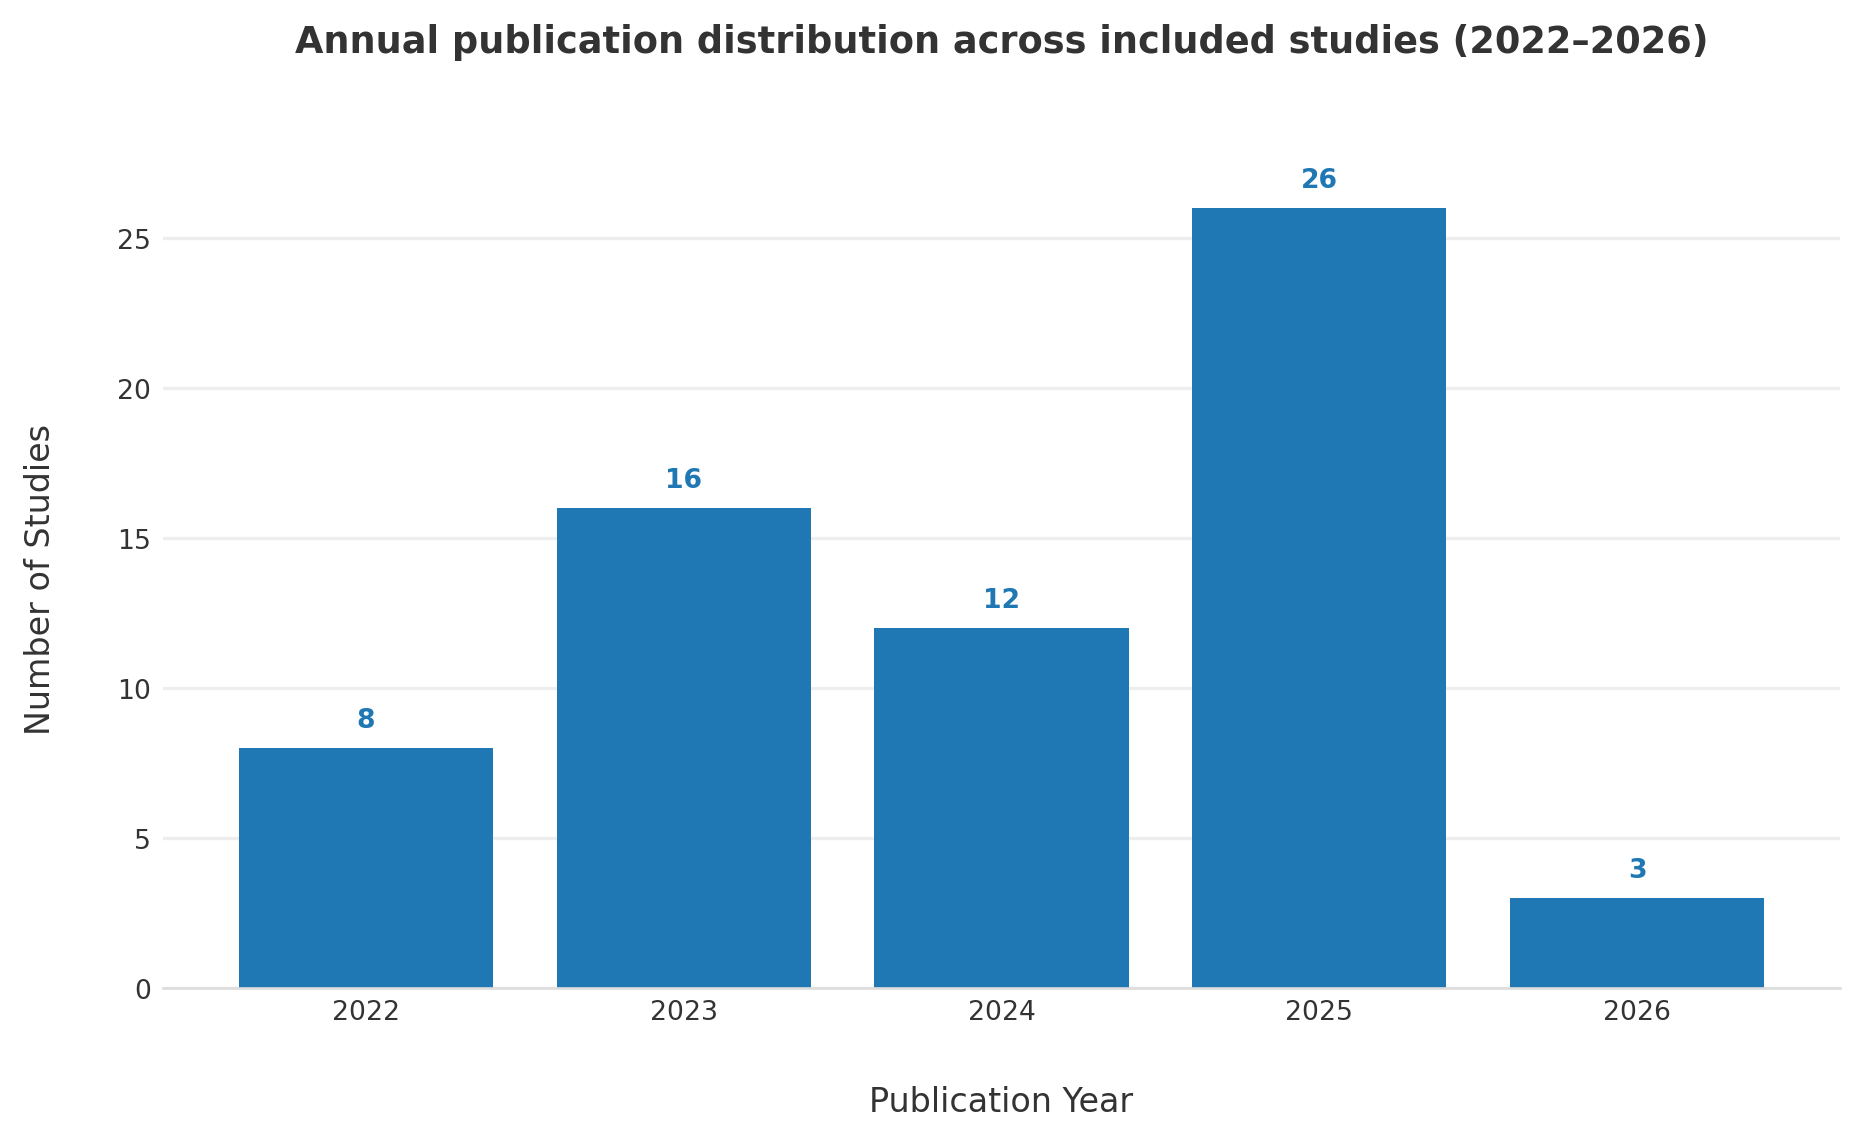

In [44]:
# ---------------------------------
# Count publications per year
# ---------------------------------
year_counts = (
    df["Year"]
    .value_counts()
    .sort_index()
)

# ---------------------------------
# Create figure
# ---------------------------------
fig, ax = plt.subplots()

bars = ax.bar(
    x=np.arange(len(year_counts)),
    height=year_counts.values,
    tick_label=year_counts.index.astype(str)
)

# ---------------------------------
# Axis formatting
# ---------------------------------
ax.spines['bottom'].set_color('#DDDDDD')

ax.tick_params(
    bottom=False,
    left=False
)

ax.yaxis.grid(True, color='#EEEEEE')
ax.xaxis.grid(False)

# ---------------------------------
# Labels and title
# ---------------------------------
ax.set_xlabel(
    "Publication Year",
    labelpad=18,
    color='#333333'
)

ax.set_ylabel(
    "Number of Studies",
    labelpad=18,
    color='#333333'
)

ax.set_title(
    "Annual publication distribution across included studies (2022–2026)",
    pad=35,
    color='#333333',
    weight='bold'
)

# ---------------------------------
# Add value labels above bars
# ---------------------------------
bar_color = bars[0].get_facecolor()

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        int(bar.get_height()),
        ha='center',
        va='bottom',
        color=bar_color,
        weight='bold'
    )

# ---------------------------------
# Layout
# ---------------------------------
fig.tight_layout(pad=2)

# ---------------------------------
# Create output directory
# ---------------------------------
Path("data/figures/litRES").mkdir(
    parents=True,
    exist_ok=True
)

# ---------------------------------
# Save figure
# ---------------------------------
plt.savefig(
    "data/figures/litRES/annual_publication_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()